# ITI vs In-task Ripple Rate + UMAP + Silhouette

- Ripple state labels come **only from `q.Rdata(block).Relem` + `Rtr`**.
- `0 = In-task`, `1 = ITI`, `-1 = Excluded`.
- Excluded ripples:
  - `Rtr < 0` (before the first trial)
  - first valid trial + Relem column 8 (`ITI pre`)
  - last valid trial + Relem column 7 (`ITI post`)
- UMAP uses the same 60-D `binsize_10` ripple features as the previous UMAP notebook.
- To guarantee row alignment, features and labels are loaded **block-by-block in the same patient/channel/block order**, with an assertion for every block before concatenation.


In [1]:
import os
import re
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.stats import wilcoxon
from sklearn.metrics import silhouette_score
import umap.umap_ as umap

In [2]:
pt_ch_mapping = {
    "EC130_200": [1, 13],
    "EC133_200": [282, 291, 292, 293],
    "EC135_200": [303],
    "EC137_200": [257, 258, 259, 269],
    "EC143_200": [339],
    "EC157_200": [321, 332, 333, 334],
    "EC162_200": [85, 86],
    "EC175_200": [301, 302],
    "EC183_200": [290],
    "EC186_200": [299, 300, 301],
    "EC187_200": [309, 310],
    "EC191_200": [2, 3, 4],
    "EC196_200": [300, 301, 303],
    "EC219_200": [399, 400, 402, 403],
    "EC220_200": [53, 54, 76, 77],
    "EC221_200": [376, 377],
    "EC222_200": [267, 268, 269, 270],
}

empty_blocks = {
    "EC133_ch282": {"B67"},
    "EC137_ch259": {"B176"},
    "EC183_ch290": {"B132", "B139", "B142"},
    "EC220_ch55": {"B24", "B27"},
    "EC220_ch75": {"B24", "B27"},
    "EC221_ch375": {"B36", "B47"},
    "EC221_ch374": {"B36", "B47"},
    "EC196_ch302": {"B21"},
    "EC183_ch289": {"B132", "B139", "B142", "B164"},
    "EC175_ch303": {"B11"},
    "EC157_ch322": {"B46"},
    "EC143_ch330": {"B35"},
    "EC137_ch260": {"B158", "B185"},
    "EC133_ch294": {"B60", "B67"},
    "EC133_ch281": {"B60", "B67"},
    "EC130_ch2": {"B8"},
}

pathname_reaction = "/scratch/dazhang/MATLAB/"
rr_root = "/data/an/transformed/RR_h_referential_wSPKS/"

In [3]:
def load_rdata_field(f, field):
    """Load q/Rdata/<field>, preserving MATLAB block order."""
    path = f["q"]["Rdata"][field]
    data = np.array(path)

    results = []
    if data.dtype == object:
        for ref in data.flatten():
            if isinstance(ref, h5py.Reference):
                results.append(np.array(f[ref]))
    else:
        results.append(data)

    return results


def load_block_names(f):
    """Read q/blocks as strings in MATLAB order."""
    block_names = []

    for ref in f["q"]["blocks"][:].flatten(order="F"):
        if isinstance(ref, h5py.Reference):
            dataset = f[ref][:]
            text = "".join(chr(int(c)) for c in dataset.flatten())
            block_names.append(text)

    return block_names


def load_tinfo_block_names(f):
    """Load MATLAB q.tinfo(:,2), i.e. block name for each trial."""
    tinfo = np.array(f["q"]["tinfo"])

    if tinfo.shape[0] == 5:
        refs = tinfo[1, :]
    elif tinfo.shape[1] == 5:
        refs = tinfo[:, 1]
    else:
        raise ValueError(f"Unexpected q.tinfo shape: {tinfo.shape}")

    block_names = []

    for ref in refs:
        if isinstance(ref, h5py.Reference) and ref:
            arr = np.array(f[ref])
            text = "".join(chr(int(x)) for x in arr.flatten())
            block_names.append(text)
        else:
            block_names.append("")

    return np.array(block_names)


def normalize_relem(relem):
    """Normalize MATLAB Relem to N_ripples x 8."""
    relem = np.asarray(relem)

    if relem.ndim == 2 and relem.shape[0] == 8 and relem.shape[1] != 8:
        relem = relem.T

    if relem.ndim != 2 or relem.shape[1] != 8:
        raise ValueError(f"Unexpected Relem shape: {relem.shape}")

    return relem


def get_state_labels_from_relem(relem, rtr):
    """
    Return one label per ripple:
      0 = In-task
      1 = ITI
     -1 = Excluded
    """
    relem = normalize_relem(relem)
    rtr = np.asarray(rtr).reshape(-1)

    if len(rtr) != relem.shape[0]:
        raise ValueError(
            f"Rtr/Relem mismatch: Rtr={len(rtr)}, Relem={relem.shape[0]}"
        )

    valid_rtr = rtr[rtr >= 0]

    if len(valid_rtr) == 0:
        return np.full(relem.shape[0], -1, dtype=int)

    first_trial = np.min(valid_rtr)
    last_trial = np.max(valid_rtr)

    before_block_mask = rtr < 0

    # MATLAB column 8 = ITI pre
    first_trial_ITIpre_mask = ((rtr == first_trial) & (relem[:, 7] != 0))
    # MATLAB column 7 = ITI post
    last_trial_ITIpost_mask = ((rtr == last_trial) & (relem[:, 6] != 0))

    excluded_mask = (before_block_mask | first_trial_ITIpre_mask | last_trial_ITIpost_mask)
    intask_mask = (np.any(relem[:, 0:6] != 0, axis=1) & ~excluded_mask)
    iti_mask = (np.any(relem[:, 6:8] != 0, axis=1) & ~excluded_mask)

    labels = np.full(relem.shape[0], -1, dtype=int)
    labels[intask_mask] = 0
    labels[iti_mask] = 1

    return labels


def count_state_from_relem(relem, rtr):
    relem = normalize_relem(relem)
    rtr = np.asarray(rtr).reshape(-1)

    if len(rtr) != relem.shape[0]:
        raise ValueError(
            f"Rtr/Relem mismatch: Rtr={len(rtr)}, Relem={relem.shape[0]}"
        )

    valid_rtr = rtr[rtr >= 0]

    if len(valid_rtr) == 0:
        return {
            "n_labels": relem.shape[0],
            "n_intask": 0,
            "n_iti": 0,
            "n_excluded": relem.shape[0],
            "n_before_block": int((rtr < 0).sum()),
            "n_first_trial_ITIpre": 0,
            "n_last_trial_ITIpost": 0,
            "n_unclassified": int((rtr >= 0).sum()),
        }

    first_trial = np.min(valid_rtr)
    last_trial = np.max(valid_rtr)

    before_block_mask = rtr < 0
    first_trial_ITIpre_mask = ((rtr == first_trial)& (relem[:, 7] != 0))
    last_trial_ITIpost_mask = ((rtr == last_trial)& (relem[:, 6] != 0))

    excluded_mask = (before_block_mask | first_trial_ITIpre_mask | last_trial_ITIpost_mask)
    intask_mask = (np.any(relem[:, 0:6] != 0, axis=1) & ~excluded_mask)
    iti_mask = (np.any(relem[:, 6:8] != 0, axis=1) & ~excluded_mask)
    unclassified_mask = ~(intask_mask | iti_mask | excluded_mask)

    return {"n_labels": relem.shape[0],
        "n_intask": int(intask_mask.sum()),
        "n_iti": int(iti_mask.sum()),
        "n_excluded": int(excluded_mask.sum()),
        "n_before_block": int(before_block_mask.sum()),
        "n_first_trial_ITIpre": int(first_trial_ITIpre_mask.sum()),
        "n_last_trial_ITIpost": int(last_trial_ITIpost_mask.sum()),
        "n_unclassified": int(unclassified_mask.sum()),}


def binsize10_feature_file(patient_key, channel, block_index):
    """
    Return the exact binsize_10 ripple feature file for one block.
    The previous UMAP notebook used ls_ripple_*_binsize_10_* files.
    """
    path = os.path.join(pathname_reaction, patient_key)
    exact = os.path.join(path, f"ls_ripple_{patient_key}_Channel_{channel}_" f"binsize_10_Block_{block_index}.mat")

    if os.path.exists(exact):
        return exact

    # Fallback: parse candidates explicitly, never depend on glob order.
    candidates = glob.glob(os.path.join(path,f"*Channel_{channel}_binsize_10_Block_*.mat"))

    matched = []

    for filename in candidates:
        if "ls_ripple" not in os.path.basename(filename):
            continue
        if "-empty" in os.path.basename(filename):
            continue

        m = re.search(r"_Block_(\d+)", os.path.basename(filename))
        if m is not None and int(m.group(1)) == block_index:
            matched.append(filename)

    if len(matched) != 1:
        raise FileNotFoundError(
            f"{patient_key} ch{channel} Block_{block_index}: "
            f"expected 1 binsize_10 feature file, found {len(matched)}"
        )

    return matched[0]

## Build rates, corrected labels, and UMAP features in one aligned loop

This is the key merge step. For each `patient → channel → q.Rdata block`, the code:
1. computes the corrected In-task/ITI label from `Relem + Rtr`;
2. loads the corresponding `binsize_10` feature file for that exact block index;
3. asserts that the number of feature rows equals the number of labels **before** concatenating anything.

Therefore `all_specs_bin[i]` and `all_state_labels[i]` refer to the same ripple.

In [4]:
rows = []
count_mismatches = []
alignment_rows = []

state_label_blocks = []
feature_blocks = []
patient_label_blocks = []
channel_label_blocks = []
block_label_blocks = []

for patient_key, channel_list in pt_ch_mapping.items():
    pt = patient_key[:-4]  # EC130_200 -> EC130

    for channel in channel_list:
        h5_file = f"{rr_root}{pt}/AN/{pt}_AN_ch{channel}_wSPKS.mat"

        with h5py.File(h5_file, "r") as f:
            blocks = load_block_names(f)
            ripple_blocks = load_rdata_field(f, "ripples")
            relem_blocks = load_rdata_field(f, "Relem")
            rtr_blocks = load_rdata_field(f, "Rtr")

            TD = np.array(f["q"]["TD"], dtype=float)

            if TD.shape[0] == 14:
                TD = TD.T

            tinfo_block_names = load_tinfo_block_names(f)

            if not (len(blocks) == len(ripple_blocks) == len(relem_blocks) == len(rtr_blocks)):
                raise ValueError(
                    f"{pt} ch{channel}: "
                    f"blocks={len(blocks)}, "
                    f"ripples={len(ripple_blocks)}, "
                    f"Relem={len(relem_blocks)}, "
                    f"Rtr={len(rtr_blocks)}")

            for block_index, (block_name, ripples, relem, rtr) in enumerate(
                zip(blocks, ripple_blocks, relem_blocks, rtr_blocks),
                start=1
            ):
                key = f"{pt}_ch{channel}"

                if key in empty_blocks and block_name in empty_blocks[key]:
                    continue

                # --------------------------------------------------
                # Behavioral durations
                # --------------------------------------------------
                trial_idx = np.where(tinfo_block_names == block_name)[0]

                assert len(trial_idx) > 0, (
                    f"No q.TD trials found for "
                    f"{pt} ch{channel} {block_name}"
                )

                TD_block = TD[trial_idx, :]

                trial_duration_sec = (TD_block[:, 13]- TD_block[:, 0]) / 100.0

                intask_duration_sec = np.nansum(trial_duration_sec)

                task_window_start = TD_block[0, 0]
                task_window_end = TD_block[-1, 13]

                analysis_duration_sec = (task_window_end - task_window_start) / 100.0

                assert analysis_duration_sec > intask_duration_sec, (
                    f"{pt} ch{channel} {block_name}: "
                    f"analysis={analysis_duration_sec:.3f}s, "
                    f"intask={intask_duration_sec:.3f}s"
                )

                ITI_duration_sec = (analysis_duration_sec - intask_duration_sec)

                # --------------------------------------------------
                # Correct ripple labels from Relem + Rtr
                # --------------------------------------------------
                state = count_state_from_relem(relem,rtr)
                state_labels = get_state_labels_from_relem(relem, rtr)

                # --------------------------------------------------
                # Load the exact binsize_10 feature file for THIS block
                # --------------------------------------------------
                feature_file = binsize10_feature_file(patient_key,channel,block_index)

                block_features = loadmat(feature_file)["ls_ripple"]

                # CRITICAL alignment check
                assert block_features.shape[0] == len(state_labels), (
                    f"FEATURE/LABEL MISMATCH: "
                    f"{patient_key} ch{channel} "
                    f"{block_name} / Block_{block_index}: "
                    f"features={block_features.shape[0]}, "
                    f"labels={len(state_labels)}"
                )

                # The previous UMAP notebook used 60-D binsize_10 features.
                assert block_features.shape[1] == 60, (
                    f"Unexpected feature dimension: "
                    f"{patient_key} ch{channel} "
                    f"Block_{block_index}: {block_features.shape}"
                )

                state_label_blocks.append(
                    state_labels
                )
                feature_blocks.append(
                    block_features
                )
                patient_label_blocks.append(
                    np.repeat(pt, len(state_labels))
                )
                channel_label_blocks.append(
                    np.repeat(channel, len(state_labels))
                )
                block_label_blocks.append(
                    np.repeat(block_name, len(state_labels))
                )

                # --------------------------------------------------
                # Raw ripple-count
                # --------------------------------------------------
                ripples = np.atleast_2d(ripples)
                raw_ripple_count = int(ripples.shape[1])

                if state["n_labels"] != raw_ripple_count:
                    count_mismatches.append({
                        "patient": pt,
                        "channel": channel,
                        "block": block_name,
                        "raw_ripple_count": raw_ripple_count,
                        "Relem_count": state["n_labels"],
                    })

                assert (state["n_intask"]+state["n_iti"]+state["n_excluded"]+state["n_unclassified"]== state["n_labels"])

                alignment_rows.append({
                    "patient": pt,
                    "channel": channel,
                    "block_index": block_index,
                    "block": block_name,
                    "feature_rows": block_features.shape[0],
                    "label_rows": len(state_labels),
                    "feature_file": os.path.basename(feature_file),
                })

                rows.append({
                    "patient": pt,
                    "channel": channel,
                    "block_index": block_index,
                    "block": block_name,
                    "analysis_duration_sec": analysis_duration_sec,
                    "intask_duration_sec": intask_duration_sec,
                    "ITI_duration_sec": ITI_duration_sec,
                    "raw_ripple_count": raw_ripple_count,
                    "intask_ripple_count": state["n_intask"],
                    "ITI_ripple_count": state["n_iti"],
                    "excluded_ripple_count": state["n_excluded"],
                    "before_block_ripple_count": state["n_before_block"],
                    "first_trial_ITIpre_count": state["n_first_trial_ITIpre"],
                    "last_trial_ITIpost_count": state["n_last_trial_ITIpost"],
                    "unclassified_ripple_count": state["n_unclassified"],
                    "intask_rate_hz":
                        state["n_intask"] / intask_duration_sec,
                    "ITI_rate_hz":
                        state["n_iti"] / ITI_duration_sec,
                })

block_df = pd.DataFrame(rows)
alignment_df = pd.DataFrame(alignment_rows)

all_state_labels = np.concatenate(state_label_blocks)
all_specs_bin = np.concatenate(feature_blocks, axis=0)
all_patient_labels = np.concatenate(patient_label_blocks)
all_channel_labels = np.concatenate(channel_label_blocks)
all_block_labels = np.concatenate(block_label_blocks)

print("Block/channel rows:", len(block_df))
print("Raw-ripple vs Relem-count mismatches:", len(count_mismatches))
print("Feature matrix:", all_specs_bin.shape)
print("State labels:", all_state_labels.shape)

assert all_specs_bin.shape[0] == len(all_state_labels)
assert len(all_patient_labels) == len(all_state_labels)
assert len(all_channel_labels) == len(all_state_labels)
assert len(all_block_labels) == len(all_state_labels)

print("\nCorrected label counts")
print("In-task:", np.sum(all_state_labels == 0))
print("ITI:", np.sum(all_state_labels == 1))
print("Excluded:", np.sum(all_state_labels == -1))

if count_mismatches:
    print("\nFirst 10 raw-ripple/Relem mismatches:")
    print(pd.DataFrame(count_mismatches).head(10))

Block/channel rows: 132
Raw-ripple vs Relem-count mismatches: 0
Feature matrix: (31847, 60)
State labels: (31847,)

Corrected label counts
In-task: 20504
ITI: 9034
Excluded: 2309


In [5]:
# Alignment QC: every row should have feature_rows == label_rows
assert np.all( alignment_df["feature_rows"].to_numpy() == alignment_df["label_rows"].to_numpy())

print(
    "All block-level feature/label alignment checks passed:",
    len(alignment_df),
    "blocks"
)

alignment_df.head(10)

All block-level feature/label alignment checks passed: 132 blocks


,patient,channel,block_index,block,feature_rows,label_rows,feature_file
0,EC130,1,1,B1,300,300,ls_ripple_EC130_Channel_1_binsize_10_Block_1.mat
1,EC130,1,2,B6,115,115,ls_ripple_EC130_Channel_1_binsize_10_Block_2.mat
2,EC130,1,3,B8,254,254,ls_ripple_EC130_Channel_1_binsize_10_Block_3.mat
3,EC130,13,1,B1,327,327,ls_ripple_EC130_Channel_13_binsize_10_Block_1.mat
4,EC130,13,2,B6,198,198,ls_ripple_EC130_Channel_13_binsize_10_Block_2.mat
5,EC130,13,3,B8,271,271,ls_ripple_EC130_Channel_13_binsize_10_Block_3.mat
6,EC133,282,1,B60,178,178,ls_ripple_EC133_Channel_282_binsize_10_Block_1...
7,EC133,291,1,B60,170,170,ls_ripple_EC133_Channel_291_binsize_10_Block_1...
8,EC133,291,2,B67,151,151,ls_ripple_EC133_Channel_291_binsize_10_Block_2...
9,EC133,292,1,B60,168,168,ls_ripple_EC133_Channel_292_binsize_10_Block_1...


In [6]:
block_df.loc[
    block_df["patient"] == "EC143",
    [
        "patient",
        "channel",
        "block",
        "raw_ripple_count",
        "intask_ripple_count",
        "ITI_ripple_count",
        "excluded_ripple_count",
        "before_block_ripple_count",
        "first_trial_ITIpre_count",
        "last_trial_ITIpost_count",
        "intask_rate_hz",
        "ITI_rate_hz",
    ]
]

,patient,channel,block,raw_ripple_count,intask_ripple_count,ITI_ripple_count,excluded_ripple_count,before_block_ripple_count,first_trial_ITIpre_count,last_trial_ITIpost_count,intask_rate_hz,ITI_rate_hz
45,EC143,339,B18,365,176,125,64,26,3,35,0.743651,0.956828
46,EC143,339,B34,112,88,23,1,1,0,0,0.447291,0.477674
47,EC143,339,B35,404,260,97,47,40,4,3,1.118472,1.075269


## Patient-level ripple rates

In [7]:
patient_df = (
    block_df.groupby("patient", sort=False)
    .agg(
        total_intask_ripples=("intask_ripple_count", "sum"),
        total_ITI_ripples=("ITI_ripple_count", "sum"),
        total_intask_duration_sec=("intask_duration_sec", "sum"),
        total_ITI_duration_sec=("ITI_duration_sec", "sum"),
    )
    .reset_index()
)

patient_df["intask_rate_hz"] = (
    patient_df["total_intask_ripples"]
    / patient_df["total_intask_duration_sec"]
)

patient_df["ITI_rate_hz"] = (
    patient_df["total_ITI_ripples"]
    / patient_df["total_ITI_duration_sec"]
)

patient_df

,patient,total_intask_ripples,total_ITI_ripples,total_intask_duration_sec,total_ITI_duration_sec,intask_rate_hz,ITI_rate_hz
0,EC130,797,468,1055.24,578.76,0.755278,0.808625
1,EC133,813,326,1256.11,713.16,0.647236,0.457120
2,EC135,230,101,285.26,150.02,0.806282,0.673244
3,EC137,4439,1992,5513.75,2602.60,0.805078,0.765388
4,EC143,524,245,665.87,269.00,0.786940,0.910781
5,EC157,3264,1137,3611.20,1438.80,0.903855,0.790242
6,EC162,1364,656,1552.58,871.66,0.878538,0.752587
7,EC175,408,100,510.76,193.44,0.798810,0.516956
8,EC183,157,57,196.00,80.46,0.801020,0.708427
9,EC186,1238,432,1506.09,665.61,0.821996,0.649029


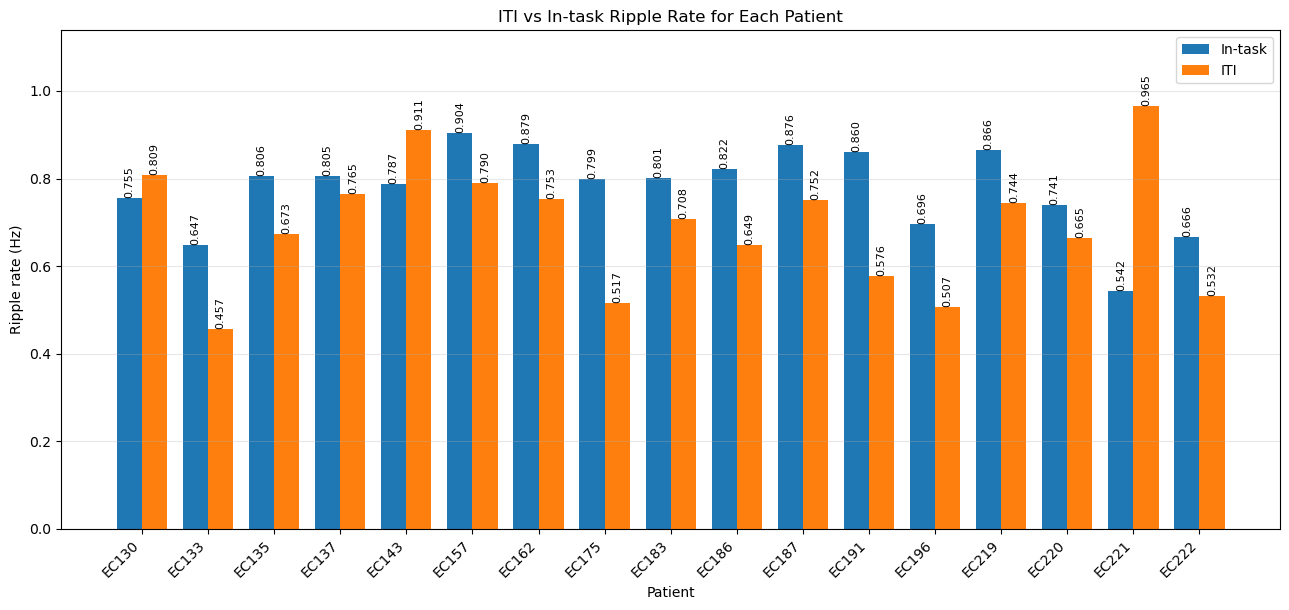

Across-patient mean in-task rate: 0.7795665693597315
Across-patient mean ITI rate: 0.6926155535003718


In [8]:
patients = patient_df["patient"].tolist()
intask_rates = patient_df["intask_rate_hz"].to_numpy()
iti_rates = patient_df["ITI_rate_hz"].to_numpy()

x = np.arange(len(patients))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6.2))

bars1 = ax.bar(
    x - width / 2,
    intask_rates,
    width,
    label="In-task"
)
bars2 = ax.bar(
    x + width / 2,
    iti_rates,
    width,
    label="ITI"
)

for bars in (bars1, bars2):
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

ax.set_xlabel("Patient")
ax.set_ylabel("Ripple rate (Hz)")
ax.set_title("ITI vs In-task Ripple Rate for Each Patient")
ax.set_xticks(x)
ax.set_xticklabels(patients, rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

max_value = np.nanmax(
    np.concatenate([intask_rates, iti_rates])
)
ax.set_ylim(
    0,
    max_value * 1.18 if max_value > 0 else 1
)

plt.tight_layout()
plt.show()

print(
    "Across-patient mean in-task rate:",
    np.nanmean(intask_rates)
)
print(
    "Across-patient mean ITI rate:",
    np.nanmean(iti_rates)
)

N patients: 17
Median In-task rate: 0.8010204081632653
Median ITI rate: 0.708426547352722
Wilcoxon statistic: 26.0
p-value: 0.0149993896484375


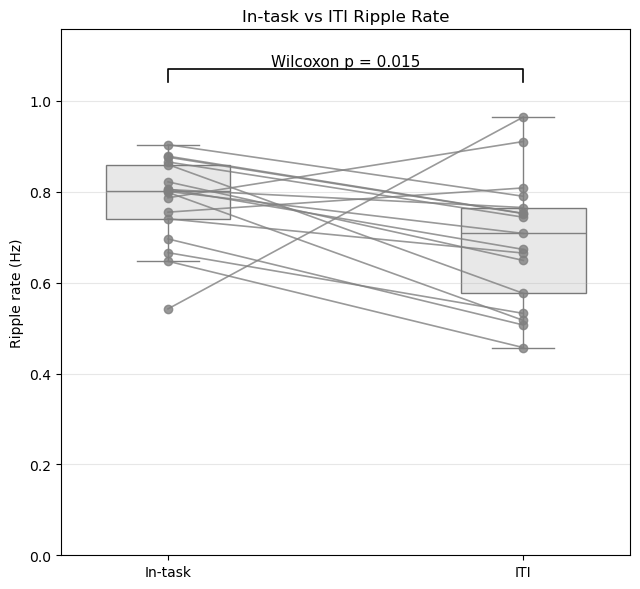

In [9]:
patients = patient_df["patient"].to_numpy()
intask_rates = patient_df["intask_rate_hz"].to_numpy()
iti_rates = patient_df["ITI_rate_hz"].to_numpy()

valid = (
    np.isfinite(intask_rates)
    & np.isfinite(iti_rates)
)

patients_valid = patients[valid]
intask_valid = intask_rates[valid]
iti_valid = iti_rates[valid]

stat, p_value = wilcoxon(
    intask_valid,
    iti_valid,
    alternative="two-sided"
)

print("N patients:", len(intask_valid))
print("Median In-task rate:", np.median(intask_valid))
print("Median ITI rate:", np.median(iti_valid))
print("Wilcoxon statistic:", stat)
print("p-value:", p_value)

fig, ax = plt.subplots(figsize=(6.5, 6))

box = ax.boxplot(
    [intask_valid, iti_valid],
    positions=[0, 1],
    widths=0.35,
    patch_artist=True,
    showfliers=False,
    # whis=(0, 100),
    zorder=1
)

for patch in box["boxes"]:
    patch.set_facecolor("lightgray")
    patch.set_alpha(0.5)

for item in ["medians", "whiskers", "caps"]:
    for artist in box[item]:
        artist.set_color("gray")

for i in range(len(intask_valid)):
    ax.plot(
        [0, 1],
        [intask_valid[i], iti_valid[i]],
        marker="o",
        linewidth=1.2,
        alpha=0.8,
        color="gray",
        zorder=3
    )

y_max = max(
    np.max(intask_valid),
    np.max(iti_valid)
)
y = y_max * 1.08
h = y_max * 0.03

ax.plot(
    [0, 0, 1, 1],
    [y, y + h, y + h, y],
    linewidth=1.2,
    color="black"
)

p_text = (
    "p < 0.001"
    if p_value < 0.001
    else f"p = {p_value:.3f}"
)

ax.text(
    0.5,
    y + h,
    f"Wilcoxon {p_text}",
    ha="center",
    va="bottom",
    fontsize=11
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["In-task", "ITI"])
ax.set_ylabel("Ripple rate (Hz)")
ax.set_title("In-task vs ITI Ripple Rate")
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(0, y_max * 1.20)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## UMAP using the original 60-D binsize_10 ripple features

In [10]:
# Same UMAP settings as the previous UMAP notebook
embedding = umap.UMAP(
    n_components=2,
    min_dist=0.2,
    metric="euclidean",
    n_neighbors=15,
    random_state=42,
    n_epochs=100,
    verbose=True
).fit_transform(all_specs_bin)

print("Feature matrix:", all_specs_bin.shape)
print("UMAP embedding:", embedding.shape)
print("Corrected labels:", all_state_labels.shape)

assert embedding.shape[0] == len(all_state_labels)

UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Tue Sep 15 21:09:24 2026 Construct fuzzy simplicial set
Tue Sep 15 21:09:24 2026 Finding Nearest Neighbors
Tue Sep 15 21:09:24 2026 Building RP forest with 14 trees


/home/dazhang/anaconda3/envs/klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Tue Sep 15 21:09:27 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Tue Sep 15 21:09:40 2026 Finished Nearest Neighbor Search
Tue Sep 15 21:09:42 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Tue Sep 15 21:09:47 2026 Finished embedding
Feature matrix: (31847, 60)
UMAP embedding: (31847, 2)
Corrected labels: (31847,)


In [11]:
# Exclude boundary ripples from the In-task vs ITI comparison
valid_state_mask = all_state_labels >= 0

embedding_valid = embedding[valid_state_mask]
state_valid = all_state_labels[valid_state_mask]

print("Valid ripples:", len(state_valid))
print("In-task:", np.sum(state_valid == 0))
print("ITI:", np.sum(state_valid == 1))

assert set(np.unique(state_valid)) == {0, 1}

Valid ripples: 29538
In-task: 20504
ITI: 9034


### Silhouette score

With tens of thousands of ripples, an exact silhouette calculation is expensive because it scales approximately quadratically with sample count. The cell below uses a reproducible random sample of up to 5,000 valid ripples. Set `silhouette_sample_size = None` if you explicitly want the full calculation and have sufficient compute time.

In [12]:
# silhouette_sample_size = min(
#     5000,
#     len(state_valid)
# )

# silhouette_umap = silhouette_score(
#     embedding_valid,
#     state_valid,
#     sample_size=silhouette_sample_size,
#     random_state=42
# )

# print(
#     f"UMAP-space silhouette score "
#     f"(sample n={silhouette_sample_size}):",
#     silhouette_umap
# )

silhouette_umap = silhouette_score(embedding_valid, state_valid)

print("UMAP-space silhouette score (all valid ripples):",silhouette_umap)

UMAP-space silhouette score (all valid ripples): 0.0006684294


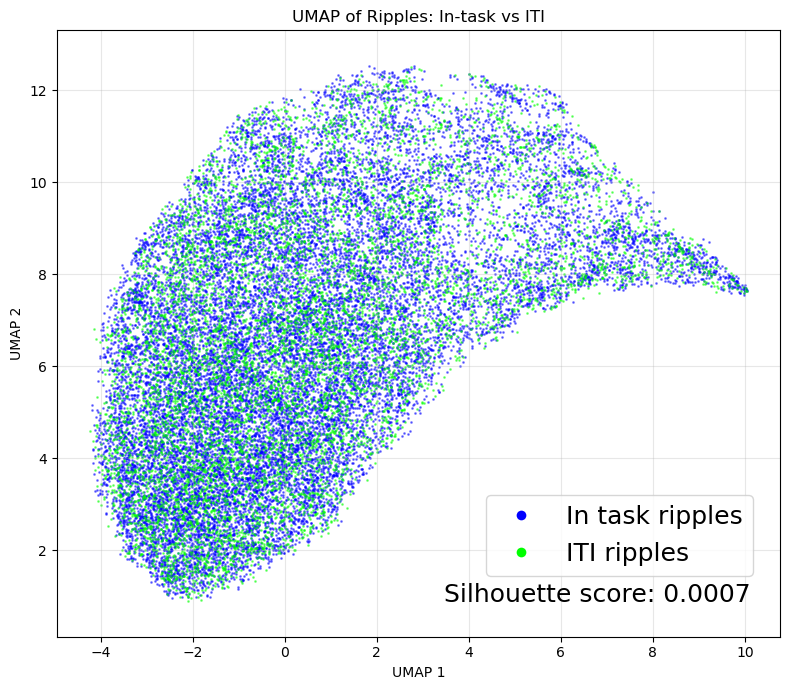

In [13]:
from matplotlib.lines import Line2D
intask_color = [0, 0, 1]  # neutral gray
iti_color = [0, 1, 0]      # deep plum

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    embedding_valid[state_valid == 0, 0],
    embedding_valid[state_valid == 0, 1],
    s=1.0,
    alpha=0.45,
    color=intask_color,
    label="In task ripples"
)

ax.scatter(
    embedding_valid[state_valid == 1, 0],
    embedding_valid[state_valid == 1, 1],
    s=1.0,
    alpha=0.45,
    color=iti_color,
    label="ITI ripples"
)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP of Ripples: In-task vs ITI")

# Custom legend
legend_handles = [
    Line2D(
        [], [],
        linestyle="none",
        marker="o",
        markerfacecolor=intask_color,
        markeredgecolor="none",
        markersize=7,
        label="In task ripples"
    ),
    Line2D(
        [], [],
        linestyle="none",
        marker="o",
        markerfacecolor=iti_color,
        markeredgecolor="none",
        markersize=7,
        label="ITI ripples"
    )
]

legend = ax.legend(
    handles=legend_handles,
    loc="lower right",
    bbox_to_anchor=(0.98, 0.08),
    frameon=True,
    fontsize=18
)

fig.canvas.draw()

legend_bbox = legend.get_window_extent(
    renderer=fig.canvas.get_renderer()
).transformed(ax.transAxes.inverted())

ax.text(
    legend_bbox.x1,
    legend_bbox.y0 - 0.015,
    f"Silhouette score: {silhouette_umap:.4f}",
    transform=ax.transAxes,
    fontsize=18,
    ha="right",
    va="top"
)

ax.grid(True, alpha=0.3)
ax.axis("equal")

plt.tight_layout()
plt.show()

In [14]:
from scipy.io import savemat
import numpy as np

intrial_vs_iti_text = np.where(state_valid == 0, "In-task", "ITI")

savemat(
    "ITI_intask_UMAP_values.mat",
    {
        "UMAP1": embedding_valid[:, 0],
        "UMAP2": embedding_valid[:, 1],
        "IntrialVs_ITI_label": state_valid,
        "IntrialVs_ITI": intrial_vs_iti_text
    }
)

print("Saved: ITI_intask_UMAP_values.mat")

Saved: ITI_intask_UMAP_values.mat


In [15]:
# Optional: a ripple-level table for debugging/alignment
ripple_df = pd.DataFrame({
    "patient": all_patient_labels,
    "channel": all_channel_labels,
    "block": all_block_labels,
    "state_label": all_state_labels,
    "UMAP1": embedding[:, 0],
    "UMAP2": embedding[:, 1],
})

ripple_df["state"] = ripple_df["state_label"].map({
    -1: "Excluded",
     0: "In-task",
     1: "ITI",
})

ripple_df.head()

,patient,channel,block,state_label,UMAP1,UMAP2,state
0,EC130,1,B1,-1,-0.041563,9.558045,Excluded
1,EC130,1,B1,-1,0.561229,9.881820,Excluded
2,EC130,1,B1,-1,2.254460,5.114822,Excluded
3,EC130,1,B1,-1,-1.349050,4.263981,Excluded
4,EC130,1,B1,-1,2.051948,9.197834,Excluded
